# Задание 2.1 - Нейронные сети

В этом задании вы реализуете и натренируете настоящую нейроную сеть своими руками!

В некотором смысле это будет расширением прошлого задания - нам нужно просто составить несколько линейных классификаторов вместе!

<img src="https://i.redd.it/n9fgba8b0qr01.png" alt="Stack_more_layers" width="400px"/>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
from dataset import load_svhn, random_split_train_val
from gradient_check import check_layer_gradient, check_layer_param_gradient, check_model_gradient
from layers import FullyConnectedLayer, ReLULayer
from model import TwoLayerNet
from trainer import Trainer, Dataset
from optim import SGD, MomentumSGD
from metrics import multiclass_accuracy

# Загружаем данные

И разделяем их на training и validation.

In [4]:
def prepare_for_neural_network(train_X, test_X):
    train_flat = train_X.reshape(train_X.shape[0], -1).astype(float) / 255.0
    test_flat = test_X.reshape(test_X.shape[0], -1).astype(float) / 255.0
    
    # Subtract mean
    mean_image = np.mean(train_flat, axis = 0)
    train_flat -= mean_image
    test_flat -= mean_image
    
    return train_flat, test_flat
    
train_X, train_y, test_X, test_y = load_svhn("data", max_train=10000, max_test=1000)    
train_X, test_X = prepare_for_neural_network(train_X, test_X)
# Split train into train and val
train_X, train_y, val_X, val_y = random_split_train_val(train_X, train_y, num_val = 1000)

# Как всегда, начинаем с кирпичиков

Мы будем реализовывать необходимые нам слои по очереди. Каждый слой должен реализовать:
- прямой проход (forward pass), который генерирует выход слоя по входу и запоминает необходимые данные
- обратный проход (backward pass), который получает градиент по выходу слоя и вычисляет градиент по входу и по параметрам

Начнем с ReLU, у которого параметров нет.

In [7]:
# TODO: Implement ReLULayer layer in layers.py
# Note: you'll need to copy implementation of the gradient_check function from the previous assignment

X = np.array([[1,-2,3],
              [-1, 2, 0.1]
              ])

assert check_layer_gradient(ReLULayer(), X)

Gradient check passed!


А теперь реализуем полносвязный слой (fully connected layer), у которого будет два массива параметров: W (weights) и B (bias).

Все параметры наши слои будут использовать для параметров специальный класс `Param`, в котором будут храниться значения параметров и градиенты этих параметров, вычисляемые во время обратного прохода.

Это даст возможность аккумулировать (суммировать) градиенты из разных частей функции потерь, например, из cross-entropy loss и regularization loss.

In [11]:
# TODO: Implement FullyConnected layer forward and backward methods
assert check_layer_gradient(FullyConnectedLayer(3, 4), X)
# TODO: Implement storing gradients for W and B
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'W')
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'B')

Gradient check passed!
Gradient check passed!
Gradient check passed!


## Создаем нейронную сеть

Теперь мы реализуем простейшую нейронную сеть с двумя полносвязным слоями и нелинейностью ReLU. Реализуйте функцию `compute_loss_and_gradients`, она должна запустить прямой и обратный проход через оба слоя для вычисления градиентов.

Не забудьте реализовать очистку градиентов в начале функции.

In [12]:
# TODO: In model.py, implement compute_loss_and_gradients function
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 0)
loss = model.compute_loss_and_gradients(train_X[:2], train_y[:2])

# TODO Now implement backward pass and aggregate all of the params
check_model_gradient(model, train_X[:2], train_y[:2])

Checking gradient for layer1_w
Gradient check passed!
Checking gradient for layer1_b
Gradient check passed!
Checking gradient for layer2_w
Gradient check passed!
Checking gradient for layer2_b
Gradient check passed!


True

Теперь добавьте к модели регуляризацию - она должна прибавляться к loss и делать свой вклад в градиенты.

In [13]:
# TODO Now implement l2 regularization in the forward and backward pass
model_with_reg = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 1e1)
loss_with_reg = model_with_reg.compute_loss_and_gradients(train_X[:2], train_y[:2])
assert loss_with_reg > loss and not np.isclose(loss_with_reg, loss), \
    "Loss with regularization (%2.4f) should be higher than without it (%2.4f)!" % (loss, loss_with_reg)

check_model_gradient(model_with_reg, train_X[:2], train_y[:2])

Checking gradient for layer1_w
Gradient check passed!
Checking gradient for layer1_b
Gradient check passed!
Checking gradient for layer2_w
Gradient check passed!
Checking gradient for layer2_b
Gradient check passed!


True

Также реализуем функцию предсказания (вычисления значения) модели на новых данных.

Какое значение точности мы ожидаем увидеть до начала тренировки?

In [15]:
# Finally, implement predict function!

# TODO: Implement predict function
# What would be the value we expect?
multiclass_accuracy(model_with_reg.predict(train_X[:30]), train_y[:30]) 

np.float64(0.1)

# Допишем код для процесса тренировки

Если все реализовано корректно, значение функции ошибки должно уменьшаться с каждой эпохой, пусть и медленно. Не беспокойтесь пока про validation accuracy.

In [16]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e1)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-2)

# TODO Implement missing pieces in Trainer.fit function
# You should expect loss to go down every epoch, even if it's slow
loss_history, train_history, val_history = trainer.fit()

Loss: 2.302808, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301663, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301971, Train accuracy: 0.148222, val accuracy: 0.140000
Loss: 2.301955, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302891, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301875, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302458, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301797, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302105, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301724, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302252, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302807, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302832, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302390, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.303278, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301772, Train acc

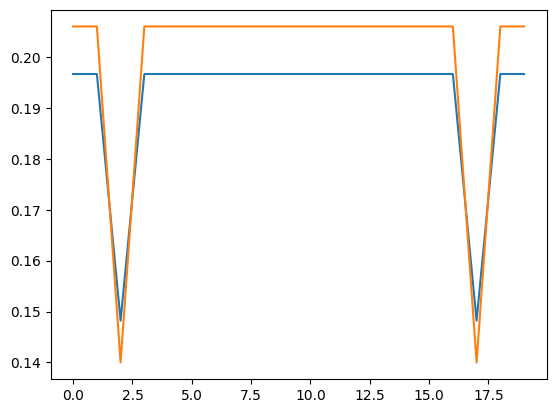

In [17]:
plt.plot(train_history)
plt.plot(val_history)

# Улучшаем процесс тренировки

Мы реализуем несколько ключевых оптимизаций, необходимых для тренировки современных нейросетей.

## Уменьшение скорости обучения (learning rate decay)

Одна из необходимых оптимизаций во время тренировки нейронных сетей - постепенное уменьшение скорости обучения по мере тренировки.

Один из стандартных методов - уменьшение скорости обучения (learning rate) каждые N эпох на коэффициент d (часто называемый decay). Значения N и d, как всегда, являются гиперпараметрами и должны подбираться на основе эффективности на проверочных данных (validation data). 

В нашем случае N будет равным 1.

In [18]:
# TODO Implement learning rate decay inside Trainer.fit method
# Decay should happen once per epoch

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate_decay=0.99)

initial_learning_rate = trainer.learning_rate
loss_history, train_history, val_history = trainer.fit()

assert trainer.learning_rate < initial_learning_rate, "Learning rate should've been reduced"
assert trainer.learning_rate > 0.5*initial_learning_rate, "Learning rate shouldn'tve been reduced that much!"

Loss: 2.275985, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.347515, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.264348, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.287890, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.253264, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.265011, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.212698, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.320777, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.302624, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.311032, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.234316, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.283390, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.353994, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.217454, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.378711, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.256101, Train acc

# Накопление импульса (Momentum SGD)

Другой большой класс оптимизаций - использование более эффективных методов градиентного спуска. Мы реализуем один из них - накопление импульса (Momentum SGD).

Этот метод хранит скорость движения, использует градиент для ее изменения на каждом шаге, и изменяет веса пропорционально значению скорости.
(Физическая аналогия: Вместо скорости градиенты теперь будут задавать ускорение, но будет присутствовать сила трения.)

```
velocity = momentum * velocity - learning_rate * gradient 
w = w + velocity
```

`momentum` здесь коэффициент затухания, который тоже является гиперпараметром (к счастью, для него часто есть хорошее значение по умолчанию, типичный диапазон -- 0.8-0.99).

Несколько полезных ссылок, где метод разбирается более подробно:  
http://cs231n.github.io/neural-networks-3/#sgd  
https://distill.pub/2017/momentum/

In [24]:
# TODO: Implement MomentumSGD.update function in optim.py

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-4, learning_rate_decay=0.99)

# You should see even better results than before!
loss_history, train_history, val_history = trainer.fit()

Loss: 2.322906, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.309093, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.309461, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.309681, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.312674, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.289843, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.307846, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.298318, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.306361, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.288021, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.251027, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301500, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.244592, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.292468, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.270787, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.301302, Train acc

# Ну что, давайте уже тренировать сеть!

## Последний тест - переобучимся (overfit) на маленьком наборе данных

Хороший способ проверить, все ли реализовано корректно - переобучить сеть на маленьком наборе данных.  
Наша модель обладает достаточной мощностью, чтобы приблизить маленький набор данных идеально, поэтому мы ожидаем, что на нем мы быстро дойдем до 100% точности на тренировочном наборе. 

Если этого не происходит, то где-то была допущена ошибка!

In [25]:
data_size = 15
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
trainer = Trainer(model, dataset, SGD(), learning_rate=1e-1, num_epochs=150, batch_size=5)

# You should expect this to reach 1.0 training accuracy 
loss_history, train_history, val_history = trainer.fit()

Loss: 2.330868, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.319424, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.332925, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.310017, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.284632, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 2.314683, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 2.301879, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 2.288898, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 2.338718, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 2.108699, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 2.068632, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 2.015227, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.940759, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.706864, Train accuracy: 0.333333, val accuracy: 0.000000
Loss: 2.133152, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.737188, Train acc

Теперь найдем гипепараметры, для которых этот процесс сходится быстрее.
Если все реализовано корректно, то существуют параметры, при которых процесс сходится в **20** эпох или еще быстрее.
Найдите их!

In [39]:
# Now, tweak some hyper parameters and make it train to 1.0 accuracy in 20 epochs or less

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 0)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
# TODO: Change any hyperparamers or optimizators to reach training accuracy in 20 epochs
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-1, num_epochs=20, batch_size=5)

loss_history, train_history, val_history = trainer.fit()

Loss: 2.308752, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.288549, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.200396, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.210536, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 2.554352, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.182466, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.746822, Train accuracy: 0.466667, val accuracy: 0.133333
Loss: 1.364094, Train accuracy: 0.533333, val accuracy: 0.000000
Loss: 1.829021, Train accuracy: 0.600000, val accuracy: 0.000000
Loss: 1.729208, Train accuracy: 0.533333, val accuracy: 0.000000
Loss: 1.004953, Train accuracy: 0.800000, val accuracy: 0.000000
Loss: 0.610296, Train accuracy: 0.933333, val accuracy: 0.066667
Loss: 1.522896, Train accuracy: 1.000000, val accuracy: 0.000000
Loss: 0.001489, Train accuracy: 1.000000, val accuracy: 0.000000
Loss: 0.094887, Train accuracy: 1.000000, val accuracy: 0.000000
Loss: 0.016275, Train acc

# Итак, основное мероприятие!

Натренируйте лучшую нейросеть! Можно добавлять и изменять параметры, менять количество нейронов в слоях сети и как угодно экспериментировать. 

Добейтесь точности лучше **60%** на validation set.

In [44]:
# Let's train the best one-hidden-layer network we can

learning_rates = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
reg_strength = [0, 1e-6, 1e-5, 1e-4, 1e-3]
learning_rate_decay = 0.999
hidden_layer_size = 128
num_epochs = 20
batch_size = 128

best_classifier = None
best_lr = None
best_reg = None
best_val_accuracy = None

loss_history = []
train_history = []
val_history = []

# TODO find the best hyperparameters to train the network
# Don't hesitate to add new values to the arrays above, perform experiments, use any tricks you want
# You should expect to get to at least 40% of valudation accuracy
# Save loss/train/history of the best classifier to the variables above

dataset = Dataset(train_X[:2000], train_y[:2000], val_X, val_y)
for lr in learning_rates:
    for reg in reg_strength:
        print("Trying lr =", lr, "reg =", reg)

        model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = hidden_layer_size, reg = reg)
        trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=lr, num_epochs=num_epochs, batch_size=batch_size)

        tr_loss_history, tr_train_history, tr_val_history = trainer.fit()

        current_best_val = max(tr_val_history)

        if best_val_accuracy is None or current_best_val > best_val_accuracy:
            best_val_accuracy = current_best_val
            best_lr = lr
            best_reg = reg
            best_classifier = model
            loss_history = tr_loss_history
            train_history = tr_train_history
            val_history = tr_val_history



print('best validation accuracy achieved: %f' % best_val_accuracy)

Trying lr = 0.001 reg = 0
Loss: 2.301247, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.297576, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.298366, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.292606, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.291478, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.291447, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.292729, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.281764, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.293117, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.292032, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.297550, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.282038, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.274005, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.272365, Train accuracy: 0.196000, val accuracy: 0.206000
Loss: 2.306015, Train accuracy: 0.196000, val accuracy: 0.206000

In [45]:
dataset = Dataset(train_X, train_y, val_X, val_y)

model = TwoLayerNet(
    n_input=train_X.shape[1],
    n_output=10,
    hidden_layer_size=hidden_layer_size,
    reg=best_reg
)
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=best_lr, num_epochs=200, batch_size=batch_size)

loss_history, train_history, val_history = trainer.fit()


Loss: 2.170037, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 1.296848, Train accuracy: 0.418667, val accuracy: 0.425000
Loss: 1.187718, Train accuracy: 0.550000, val accuracy: 0.536000
Loss: 1.077854, Train accuracy: 0.626889, val accuracy: 0.628000
Loss: 1.359302, Train accuracy: 0.660556, val accuracy: 0.643000
Loss: 0.969796, Train accuracy: 0.674778, val accuracy: 0.635000
Loss: 0.780308, Train accuracy: 0.724556, val accuracy: 0.679000
Loss: 0.739941, Train accuracy: 0.750111, val accuracy: 0.697000
Loss: 0.802693, Train accuracy: 0.749222, val accuracy: 0.684000
Loss: 0.598493, Train accuracy: 0.766222, val accuracy: 0.698000
Loss: 0.854778, Train accuracy: 0.776222, val accuracy: 0.702000
Loss: 0.742238, Train accuracy: 0.787889, val accuracy: 0.710000
Loss: 0.947727, Train accuracy: 0.793000, val accuracy: 0.705000
Loss: 0.443030, Train accuracy: 0.809778, val accuracy: 0.726000
Loss: 0.610400, Train accuracy: 0.826444, val accuracy: 0.730000
Loss: 0.804231, Train acc

In [46]:
print(best_reg, best_lr)

1e-05 0.1


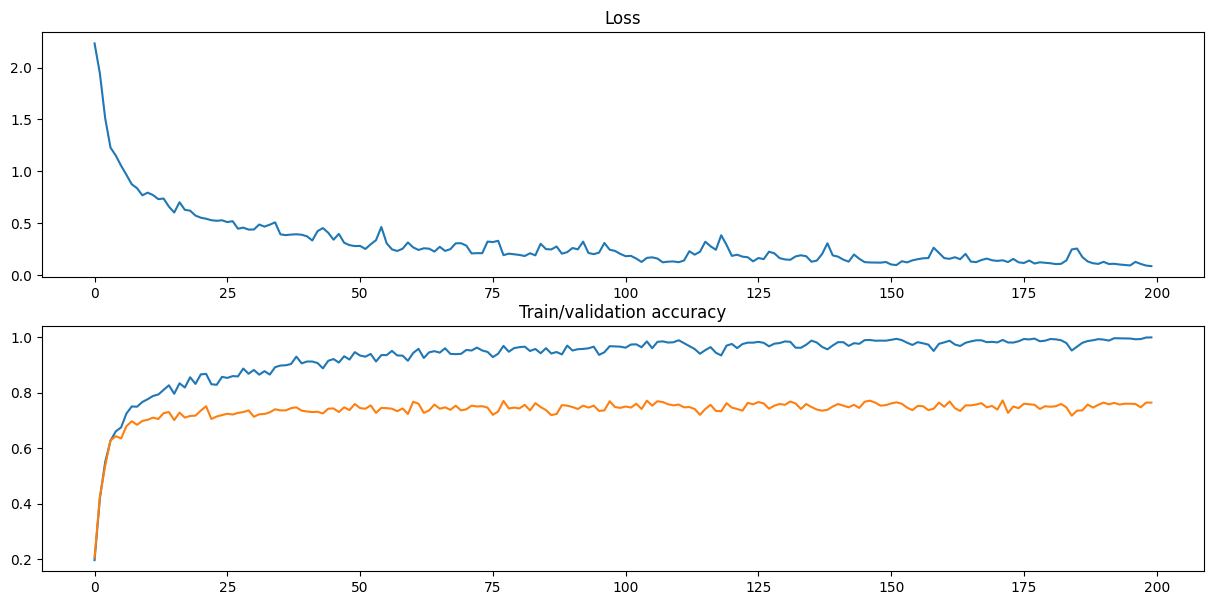

In [47]:
plt.figure(figsize=(15, 7))
plt.subplot(211)
plt.title("Loss")
plt.plot(loss_history)
plt.subplot(212)
plt.title("Train/validation accuracy")
plt.plot(train_history)
plt.plot(val_history)

# Как обычно, посмотрим, как наша лучшая модель работает на тестовых данных

In [49]:
best_classifier = model

In [50]:
test_pred = best_classifier.predict(test_X)
test_accuracy = multiclass_accuracy(test_pred, test_y)
print('Neural net test set accuracy: %f' % (test_accuracy, ))

Neural net test set accuracy: 0.741000
